In [1]:
!pip install equinox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 9.2 MB/s eta 0:00:00


In [2]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax

import numpy as np
import matplotlib.pyplot as plt

import glob
import os
import pandas as pd
import pickle
import random
import copy
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Define folder path
folder_path = '/content/drive/MyDrive/coding/romero_shots_489'
pickle_output = 'combined_data.pkl'

# Find all CSV files in the folder
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

In [4]:
dfb = pd.read_csv(all_files[0], nrows=0)
header_list = dfb.columns.tolist()

print(len(all_files))
print(all_files[:3])

489
['/content/drive/MyDrive/coding/romero_shots_489/romero2_shot_1050303014.csv', '/content/drive/MyDrive/coding/romero_shots_489/romero2_shot_1150826025.csv', '/content/drive/MyDrive/coding/romero_shots_489/romero2_shot_1150505033.csv']


In [5]:
df_list = []

for filename in all_files:
    df = pd.read_csv(filename)
    df_list.append(df)

print(df_list[0].columns)

Index(['shot', 'time', 'dip_dt', 'li', 'kappa', 'dli_dt', 'ip', 'ip_MA', 'Li',
       'vc_minus_vb', 'Vind'],
      dtype='object')


In [6]:
def moving_average(x, window=3):
    kernel = jnp.ones(window) / window
    return jnp.convolve(x, kernel, mode="same")


def backward_slopes(y, time):
    dy = y[1:] - y[:-1]
    dt = time[1:] - time[:-1]

    slopes = jnp.zeros_like(y)
    slopes = slopes.at[1:].set(dy / (dt + 1e-8))
    slopes = slopes.at[0].set(slopes[1])
    return slopes


group_size = 10
stride = 10

episodes = []

for df in df_list:

    time = jnp.array(df["time"].values)
    li = jnp.array(df["li"].values)
    ip = jnp.array(df["ip_MA"].values)
    V  = jnp.array(df["vc_minus_vb"].values)
    Vind = jnp.array(df["Vind"].values)

    Vind_slope = backward_slopes(Vind, time)

    T = len(li)

    for start in range(0, T - group_size, stride):

        init_state = {
            "li": li[start],
            "ip_MA": ip[start],
            "vc_minus_vb": V[start],
        }

        controls = {
            "time": time[start:start + group_size],
            "Vind": Vind[start:start + group_size],
            "Vind_slope": Vind_slope[start:start + group_size],
        }

        targets = {
            "li": li[start:start + group_size],
            "ip_MA": ip[start:start + group_size],
            "vc_minus_vb": V[start:start + group_size],
        }

        episodes.append((init_state, controls, targets))

In [7]:
def stack_episodes(eps):
    init_states = {
        k: jnp.stack([ep[0][k] for ep in eps])
        for k in eps[0][0].keys()
    }

    controls = {
        k: jnp.stack([ep[1][k] for ep in eps])
        for k in eps[0][1].keys()
    }

    targets = {
        k: jnp.stack([ep[2][k] for ep in eps])
        for k in eps[0][2].keys()
    }

    return init_states, controls, targets

In [8]:
n = len(episodes)
#n=200

train_end = int(0.7 * n)
val_end   = int(0.85 * n)

train_eps = episodes[:train_end]
val_eps   = episodes[train_end:val_end]
test_eps  = episodes[val_end:]

train_batch = stack_episodes(train_eps)
#train_batch = stack_episodes(train_eps[:500])
val_batch = stack_episodes(val_eps)
#val_batch = stack_episodes(val_eps[:100])
test_batch = stack_episodes(test_eps)

def check_batch_finite(batch, name):
    init_states, controls, targets = batch

    for tree_name, tree in [
        ("init_states", init_states),
        ("controls", controls),
        ("targets", targets),
    ]:
        for k, v in tree.items():
            print(name, tree_name, k, jnp.all(jnp.isfinite(v)), v.shape)

check_batch_finite(train_batch, "train")
check_batch_finite(val_batch, "val")
check_batch_finite(test_batch, "test")

train init_states li True (755,)
train init_states ip_MA True (755,)
train init_states vc_minus_vb True (755,)
train controls time True (755, 10)
train controls Vind True (755, 10)
train controls Vind_slope True (755, 10)
train targets li True (755, 10)
train targets ip_MA True (755, 10)
train targets vc_minus_vb True (755, 10)
val init_states li True (162,)
val init_states ip_MA True (162,)
val init_states vc_minus_vb True (162,)
val controls time True (162, 10)
val controls Vind True (162, 10)
val controls Vind_slope True (162, 10)
val targets li True (162, 10)
val targets ip_MA True (162, 10)
val targets vc_minus_vb True (162, 10)
test init_states li True (162,)
test init_states ip_MA True (162,)
test init_states vc_minus_vb True (162,)
test controls time True (162, 10)
test controls Vind True (162, 10)
test controls Vind_slope True (162, 10)
test targets li True (162, 10)
test targets ip_MA True (162, 10)
test targets vc_minus_vb True (162, 10)


In [9]:
class RomeroNNV(eqx.Module):
    mlp: eqx.nn.MLP
    romero_norm: float

    alpha_ip: jnp.ndarray
    alpha_li: jnp.ndarray

    def __init__(self, key):
        self.mlp = eqx.nn.MLP(
            in_size=4,
            out_size=1,
            width_size=32,
            depth=2,
            key=key,
            activation=jax.nn.softplus,
        )
        self.romero_norm = 3.6559
        # trainable parameters, ie constants/normalizations I can't figure out
        self.alpha_ip = jnp.array(1.0)
        self.alpha_li = jnp.array(1.0)

    def __call__(self, state, control):
        li = state["li"]
        ip = state["ip_MA"]
        V = state["vc_minus_vb"]
        Vind = control["Vind"]

        Vb_minus_Vr = Vind
        Vr_minus_Vb = -Vb_minus_Vr

        li_dot = self.alpha_li * (2 * Vr_minus_Vb - 2 * V) / (self.romero_norm * ip)
        ip_dot = self.alpha_ip * (2 * Vb_minus_Vr + V) / (self.romero_norm * li)

        inputs = jnp.array([li, ip, V, Vind])
        V_dot = self.mlp(inputs)[0]

        return {
            "li": li_dot,
            "ip_MA": ip_dot,
            "vc_minus_vb": V_dot,
        }

In [10]:
def step(model, state, control, dt):
    state_dot = model(state, control)
    return jax.tree_util.tree_map(
        lambda s, ds: s + dt * ds,
        state,
        state_dot,
    )

In [11]:
def rollout(model, init_state, controls, dt):
    def body_fn(state, control_t):
        control = {"Vind": control_t}
        next_state = step(model, state, control, dt)
        return next_state, next_state

    _, states = jax.lax.scan(body_fn, init_state, controls["Vind"])
    return states

In [12]:
def mse_pytree(pred, target):
    leaves_pred = jax.tree_util.tree_leaves(pred)
    leaves_target = jax.tree_util.tree_leaves(target)
    return sum(jnp.mean((p - t) ** 2) for p, t in zip(leaves_pred, leaves_target))

In [13]:
def loss_fn(model):
    preds = model(init_state, controls)

    pred_leaves = jax.tree_util.tree_leaves(preds)
    target_leaves = jax.tree_util.tree_leaves(targets)

    dt = 0.01  #initially set to 1 but changed back original delta_t

    losses = []

    for p, t in zip(pred_leaves, target_leaves):
        rel_error = (p - t) / (jnp.abs(t) + 1e-6)

        # Huber loss (delta = 0.1)
        delta = 0.1
        abs_err = jnp.abs(rel_error)

        huber = jnp.where(
            abs_err < delta,
            0.5 * rel_error**2,
            delta * (abs_err - 0.5 * delta)
        )

         # trapezoidal integration
        integrated = jnp.sum(
          0.5 * (huber[:-1] + huber[1:])
        )

        losses.append(jnp.mean(huber))

    return sum(losses)

In [14]:
def single_trajectory_loss(model, init_state, controls, targets):
    preds = model(init_state, controls)
    return trajectory_loss(preds, targets, controls)

In [15]:
#Added Learning Rate Scheduler
def make_lr_schedule():
    base_lr = 5e-3
    decay_rate = 0.995
    min_lr = 1e-4

    schedule = optax.exponential_decay(
        init_value=base_lr,
        transition_steps=1,   # per epoch
        decay_rate=decay_rate,
        staircase=False,
    )

    def lr_fn(step):
        return jnp.maximum(schedule(step), min_lr)

    return lr_fn

In [16]:
def evaluate_with_model(model, episodes):
    total = 0.0

    for init_state, controls, targets in episodes:
        preds = model(init_state, controls)
        loss = trajectory_loss(preds, targets, controls)
        total += loss

    return float(total)


def evaluate(episodes):
    return evaluate_with_model(model, episodes)

In [17]:
def trajectory_loss(preds, targets, controls):
    losses = []

    time = controls["time"]
    dt = time[1:] - time[:-1]

    # -------------------
    # Main Wang-style loss: li and ip only
    # -------------------
    for key in ["li", "ip_MA"]:
        p = preds[key]
        t = targets[key]

        rel_error = jnp.abs(t - p) / (jnp.abs(t) + 1e-6)
        huber = optax.huber_loss(rel_error, delta=0.1)

        integrated = jnp.sum(
            0.5 * (huber[:-1] + huber[1:]) * dt
        )

        losses.append(integrated)

    return sum(losses)

In [18]:
@eqx.filter_jit
def train_step_batched(model, opt_state, batch, optimizer):

    init_states, controls, targets = batch

    def loss_fn(model):
        losses = jax.vmap(
            lambda s, c, t: single_trajectory_loss(model, s, c, t),
            in_axes=(0, 0, 0)
        )(init_states, controls, targets)

        return jnp.mean(losses)

    loss, grads = eqx.filter_value_and_grad(loss_fn)(model)

    updates, opt_state = optimizer.update(
        grads,
        opt_state,
        model
    )

    model = eqx.apply_updates(model, updates)

    return model, opt_state, loss

In [19]:
@eqx.filter_jit
def evaluate_batch_jit(model, batch):
    init_states, controls, targets = batch

    losses = jax.vmap(
        lambda s, c, t: single_trajectory_loss(model, s, c, t),
        in_axes=(0, 0, 0)
    )(init_states, controls, targets)

    return jnp.mean(losses)

In [20]:
def hermite_interp(y0, y1, m0, m1, h, s):
    h00 = 2*s**3 - 3*s**2 + 1
    h10 = s**3 - 2*s**2 + s
    h01 = -2*s**3 + 3*s**2
    h11 = s**3 - s**2

    return h00*y0 + h10*h*m0 + h01*y1 + h11*h*m1


class SimFullObs(eqx.Module):
    dynamics: eqx.Module

    def interp_control(self, controls, i, s):
        time = controls["time"]
        Vind = controls["Vind"]
        slope = controls["Vind_slope"]

        t0 = time[i]
        t1 = time[i + 1]
        h = t1 - t0

        Vind_s = hermite_interp(
            Vind[i],
            Vind[i + 1],
            slope[i],
            slope[i + 1],
            h,
            s,
        )

        return {"Vind": Vind_s}

    def rk4_interval(self, state, controls, i, n_substeps=2):
      h_total = controls["time"][i + 1] - controls["time"][i]
      h = h_total / n_substeps

      def substep_fn(state, j):
          s0 = j / n_substeps
          s1 = (j + 1) / n_substeps
          sm = 0.5 * (s0 + s1)

          # Same RK4, but over sub-interval [s0, s1]
          u1 = self.interp_control(controls, i, s0)
          k1 = self.dynamics(state, u1)

          state2 = jax.tree_util.tree_map(lambda x, k: x + 0.5 * h * k, state, k1)
          u2 = self.interp_control(controls, i, sm)
          k2 = self.dynamics(state2, u2)

          state3 = jax.tree_util.tree_map(lambda x, k: x + 0.5 * h * k, state, k2)
          u3 = self.interp_control(controls, i, sm)
          k3 = self.dynamics(state3, u3)

          state4 = jax.tree_util.tree_map(lambda x, k: x + h * k, state, k3)
          u4 = self.interp_control(controls, i, s1)
          k4 = self.dynamics(state4, u4)

          next_state = jax.tree_util.tree_map(
              lambda x, k1, k2, k3, k4: x + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4),
              state, k1, k2, k3, k4
          )
          return next_state, None

      state, _ = jax.lax.scan(substep_fn, state, jnp.arange(n_substeps))
      return state

    def __call__(self, init_state, controls):
        # T samples means T-1 integration intervals
        T = controls["Vind"].shape[0]

        def step_fn(state, i):
            #next_state = self.rk4_step(state, controls, i)
            next_state = self.rk4_interval(state, controls, i, n_substeps=2)
            return next_state, next_state

        _, trajectory = jax.lax.scan(
            step_fn,
            init_state,
            jnp.arange(T - 1),
        )

        # prepend initial state so prediction length matches targets length T
        trajectory = jax.tree_util.tree_map(
            lambda x0, xs: jnp.concatenate([x0[None], xs], axis=0),
            init_state,
            trajectory,
        )

        return trajectory

In [21]:
key = jax.random.PRNGKey(0)

# Split immediately for different purposes
key, model_key, data_key = jax.random.split(key, 3)

In [22]:
model = SimFullObs(
    RomeroNNV(model_key)
)

In [23]:
lr_schedule = make_lr_schedule()

optimizer = optax.chain(
    optax.zero_nans(),
    optax.clip_by_global_norm(1.0),
    optax.adamw(
        learning_rate=lr_schedule,
        weight_decay=1e-4
    )
)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

val_history = []
train_history = []

best_val = float("inf")
best_model = copy.deepcopy(model)

num_epochs = 3000

for epoch in range(num_epochs):

    model, opt_state, train_loss = train_step_batched(
        model,
        opt_state,
        train_batch,
        optimizer
    )

    val_loss = float(evaluate_batch_jit(model, val_batch))

    train_history.append(float(train_loss))
    val_history.append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        best_model = copy.deepcopy(model)

    if epoch % 250 == 0:
        print(
            f"Epoch {epoch}, "
            f"Train Loss: {float(train_loss):.6f}, "
            f"Val Loss: {val_loss:.6f}"
        )

Epoch 0, Train Loss: 0.000488, Val Loss: 0.000538
Epoch 250, Train Loss: 0.000143, Val Loss: 0.000126
Epoch 500, Train Loss: 0.000132, Val Loss: 0.000117
Epoch 750, Train Loss: 0.000131, Val Loss: 0.000116
Epoch 1000, Train Loss: 0.000130, Val Loss: 0.000115
Epoch 1250, Train Loss: 0.000130, Val Loss: 0.000115
Epoch 1500, Train Loss: 0.000129, Val Loss: 0.000114
Epoch 1750, Train Loss: 0.000128, Val Loss: 0.000114
Epoch 2000, Train Loss: 0.000128, Val Loss: 0.000114
Epoch 2250, Train Loss: 0.000127, Val Loss: 0.000113
Epoch 2500, Train Loss: 0.000126, Val Loss: 0.000113
Epoch 2750, Train Loss: 0.000126, Val Loss: 0.000113


In [24]:
best_test_loss = float(evaluate_batch_jit(best_model, test_batch))
print(f"Final Best Test Loss: {best_test_loss:.6f}")

Final Best Test Loss: 0.000103


In [25]:
init_state, controls, targets = test_eps[0]
preds = best_model(init_state, controls)

In [26]:
targets_np = np.stack([targets["li"], targets["ip_MA"], targets["vc_minus_vb"]], axis=-1)
preds_np = np.stack([preds["li"], preds["ip_MA"], preds["vc_minus_vb"]], axis=-1)

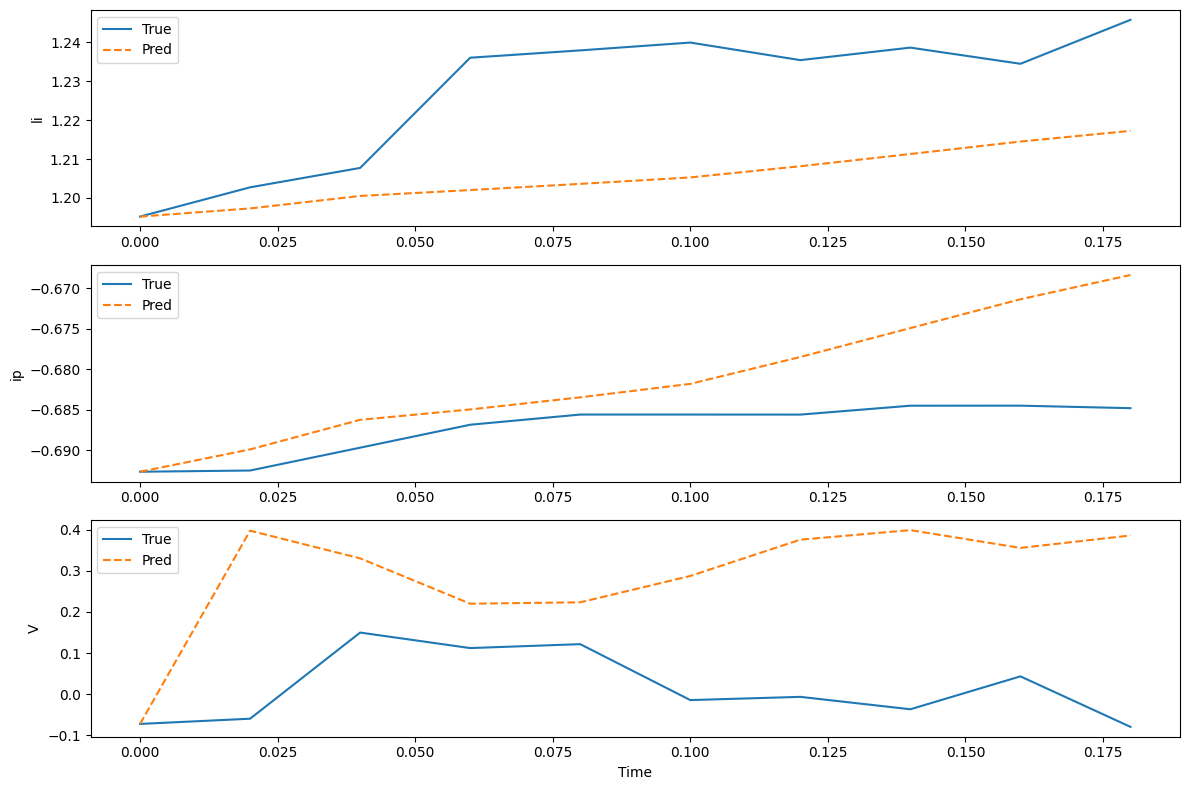

In [27]:
init_state, controls, targets = test_eps[0]
preds = best_model(init_state, controls)

targets_np = np.stack(
    [targets["li"], targets["ip_MA"], targets["vc_minus_vb"]],
    axis=-1
)
preds_np = np.stack(
    [preds["li"], preds["ip_MA"], preds["vc_minus_vb"]],
    axis=-1
)

t = np.array(controls["time"])
t = t - t[0]   # start at 0

labels = ["li", "ip", "V"]

plt.figure(figsize=(12, 8))

for i in range(3):
    plt.subplot(3, 1, i + 1)
    plt.plot(t, targets_np[:, i], label="True")
    plt.plot(t, preds_np[:, i], "--", label="Pred")
    plt.ylabel(labels[i])
    plt.legend()

plt.xlabel("Time")
plt.tight_layout()
plt.show()

In [28]:
rmse = np.sqrt(np.mean((preds_np - targets_np)**2))
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")

Root Mean Squared Error (RMSE): 0.183368


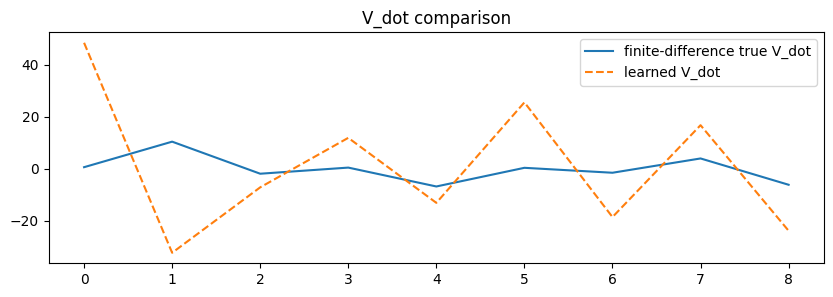

In [29]:
init_state, controls, targets = test_eps[0]
preds = best_model(init_state, controls)

time = controls["time"]
true_vdot = (targets["vc_minus_vb"][1:] - targets["vc_minus_vb"][:-1]) / (time[1:] - time[:-1])

learned_vdot = []
state = init_state

for i in range(len(time) - 1):
    u = {"Vind": controls["Vind"][i]}
    dstate = best_model.dynamics(state, u)
    learned_vdot.append(dstate["vc_minus_vb"])
    state = jax.tree_util.tree_map(
        lambda s, ds: s + (time[i+1] - time[i]) * ds,
        state,
        dstate
    )

learned_vdot = jnp.array(learned_vdot)

plt.figure(figsize=(10, 3))
plt.plot(true_vdot, label="finite-difference true V_dot")
plt.plot(learned_vdot, "--", label="learned V_dot")
plt.legend()
plt.title("V_dot comparison")
plt.show()

In [30]:
def simulate_li_ip_with_true_V(init_state, controls, targets, romero_norm=3.6559,li_scale=11.5,ip_scale=10.0):
    li0 = init_state["li"]
    ip0 = init_state["ip_MA"]

    time = controls["time"]
    Vind = controls["Vind"]
    V_true = targets["vc_minus_vb"]

    def step_fn(state, i):
        li, ip = state
        dt = time[i + 1] - time[i]

        V = V_true[i]
        Vb_minus_Vr = Vind[i]
        Vr_minus_Vb = -Vb_minus_Vr

        li_dot = li_scale * (2 * Vr_minus_Vb - 2 * V) / (romero_norm * ip)
        ip_dot = ip_scale * (2 * Vb_minus_Vr + V) / (romero_norm * li)

        next_state = (
            li + dt * li_dot,
            ip + dt * ip_dot,
        )

        return next_state, next_state

    _, traj = jax.lax.scan(
        step_fn,
        (li0, ip0),
        jnp.arange(len(time) - 1)
    )

    li_traj = jnp.concatenate([li0[None], traj[0]])
    ip_traj = jnp.concatenate([ip0[None], traj[1]])

    return li_traj, ip_traj

In [31]:
li_errors = []
ip_errors = []

for init_state, controls, targets in test_eps:
    preds = best_model(init_state, controls)

    li_err = 100 * jnp.abs(preds["li"][-1] - targets["li"][-1]) / jnp.abs(targets["li"][-1])
    ip_err = 100 * jnp.abs(preds["ip_MA"][-1] - targets["ip_MA"][-1]) / jnp.abs(targets["ip_MA"][-1])

    li_errors.append(float(li_err))
    ip_errors.append(float(ip_err))

print("li mean ± std:", np.mean(li_errors), np.std(li_errors))
print("ip mean ± std:", np.mean(ip_errors), np.std(ip_errors))

li mean ± std: 4.017652924218572 3.1544741560772502
ip mean ± std: 2.4240496106701617 1.326896819972343


In [32]:
print("alpha_ip:", float(best_model.dynamics.alpha_ip))
print("alpha_li:", float(best_model.dynamics.alpha_li))

alpha_ip: 1.9219533205032349
alpha_li: 0.49111634492874146
